## Code parameters from paper (page-11)

1) Assume MaxCut, so q=2.
2) W: adjacency/weight matrix, shape (n, n) => Symmetric, W[i,j]=weight
3) batch (they call it): number of replicas m. Think: m parallel restarts.
4) h: learnable “logits / local fields”, shape (batch, n, q) This is what Adam actually updates.
5) p = softmax(h, dim=2): probabilities, shape (batch, n, q). For each replica r and node i: p[r,i,0] + p[r,i,1] = 1

So each replica is a full probabilistic solution.

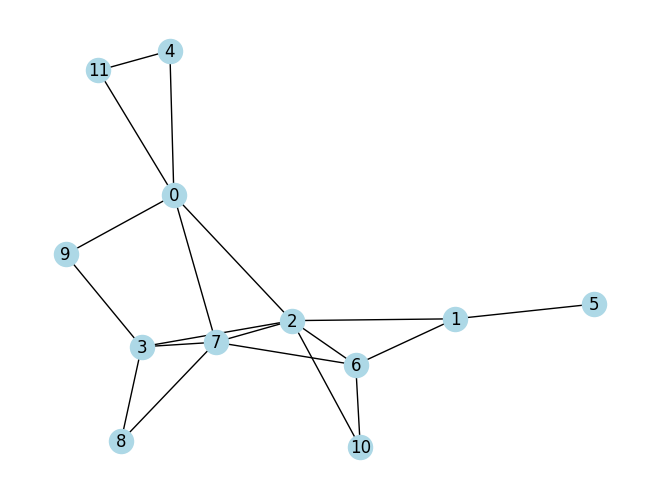

W shape: (12, 12)
Unique values in W: [0. 1.]


In [1]:
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def random_binary_undirected_graph(n_nodes=20, edge_prob=0.2, seed=1):
    """
    Simple undirected graph:
      - No self-loops
      - No multi-edges
      - Binary edges (present/absent)
    """
    G = nx.erdos_renyi_graph(n=n_nodes, p=edge_prob, seed=seed, directed=False)
    return G
def graph_to_binary_adjacency(G):
    n = G.number_of_nodes()
    W = np.zeros((n, n), dtype=np.float32)

    for u, v in G.edges():
        W[u, v] = 1.0
        W[v, u] = 1.0  # undirected symmetry

    # Ensure no self-loops in matrix form
    np.fill_diagonal(W, 0.0)
    return W
def draw_graph(G, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, with_labels=True, node_color="lightblue")
    plt.show()


G = random_binary_undirected_graph(n_nodes=12, edge_prob=0.25, seed=7)
draw_graph(G)

W = graph_to_binary_adjacency(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

In [7]:
def cut(W,p):
    return ((W @ p) * (1-p)).sum((1, 2))

def S(p):
    return -(p*p.log()).sum(2).sum(1)

def argmax_cut(W,p):
    s = torch.nn.functional.one_hot(p.argmax(dim=2), num_classes=p.shape[2])
    return config, cut(W, s) / 2

In [3]:
def balance(p):
    return (p.sum(1)**2).sum(1)-(p**2).sum(2).sum(1)

In [5]:
def solve(problem,W,batch,q,panelty,beta_range):
    n = W.shape[0]
    h = torch.rand(batch, n, q)
    optimizer = torch.optim.Adam([h], lr=0.01)
    
    for beta in beta_range:
        p = torch.softmax(h, dim=2)
        if problem == "maxcut":
            F = -cut(W,p) - S(p)/beta
        if problem == "bmincut":
            F = cut(W,p)+panelty*balance(p)-S(p)/beta
        optimizer.zero_grad()
        F.backward(gradient=torch.ones_like(F))
        optimizer.step()
    
    return argmax_cut(W, p)